# Imports

In [1]:
import os
import sys
sys.path.append('../utils')
sys.path.append('../data_utils')
import random
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item
import mesh_tools as mt
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure

# Args

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm/'
ponq_data_dir = '/data/workspaces/spanwar/dataset/ponq_dataset/gt_Quadrics'


# Load Mesh

In [21]:
def make_mask_close(sdf_input, grid_n):
    # dense grid--> sparse grid
    # mask = np.abs(sdf_input) < (1/grid_n*np.sqrt(3))
    mask = np.abs(sdf_input) < (5/grid_n)
    return mask

sdf1, sdf2 = get_item(sdf_dir, '00000002.hdf5')

In [15]:
# sdf1_nmc, sdf2_nmc = get_item('/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC', '/00000015.hdf5')

In [16]:
sdf1.shape

(33, 33, 33)

In [17]:
# dir = '/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/data/00000008_9b3d6a97e8de4aa193b81000_trimesh_000.obj'
# v, f = igl.read_triangle_mesh(dir)
# plot(v, f)

In [22]:
verts, faces, normals, values = measure.marching_cubes(sdf2, level=0)
plot(verts, faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(31.500196…

In [18]:
verts, faces, normals, values = measure.marching_cubes(sdf2, level=0)
plot(verts, faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(32.001723…

In [32]:
mt.plotSlice(sdf1*make_mask_close(sdf1, 32)*(32-1), 0.1)

interactive(children=(IntSlider(value=16, description='s', max=31), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [19]:
mt.plotSlice(sdf1*make_mask_close(sdf1, 32), 0.1)

interactive(children=(IntSlider(value=16, description='s', max=32), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [40]:
mt.plotSlice(sdf2*make_mask_close(sdf2, 32), 0.2)

interactive(children=(IntSlider(value=32, description='s', max=63), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [20]:
mt.plotSlice(sdf2*make_mask_close(sdf2, 32), 0.1)

interactive(children=(IntSlider(value=32, description='s', max=64), Output()), _dom_classes=('widget-interact'…

<function mesh_tools.plotSlice.<locals>.<lambda>(s)>

# Load Dataset

In [10]:
def vdb_marching_cubes(out: fvnn.VDBTensor):
    '''computes marching cubes for a VDBTensor'''
    nv, nf, _ = out.grid.marching_cubes(out.data)
    return nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()

def fetch_numpy_values(grid: fvdb.GridBatch, arr: np.array, size:int):
    '''fetches values from a numpy array based on the ijk indices in the grid'''
    # print(arr.shape)
    ijk = grid.ijk.jdata.cpu().detach().numpy()+(size-1)//2
    # print(ijk.shape, ijk.min(), ijk.max())
    # print(arr.shape, arr.min(), arr.max())
    # print(ijk[:, 0], ijk[:, 1], ijk[:, 2])
    values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
    # print(values.shape, values.min(), values.max())
    # print('#'*20)
    return torch.tensor(values, dtype=torch.float32, device=grid.device)

def custom_subdivide_grid(grid: fvdb.GridBatch):
    '''custom subdivision of a grid to create a finer grid:
        [0,    1,    2] -->
        [0, 1, 2, 3, 4]'''
    ijk = grid.ijk.jdata
    m3g = torch.tensor(mt.mesh_grid(3),device=device)-1
    new_ijk = (2*ijk[:, None, :]+ m3g[None, :, :]).view(-1, 3)
    print(ijk, new_ijk)
    return fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), origins=grid.origins, voxel_sizes=grid.voxel_sizes/2)
   
def sdf_to_vdb(sdf_grid, large_sdf_grid, mask, size=33):
    '''takes SDF pair grids and a mask, returns small and large VDBTensors. SDF values scaled by size'''
    #  create a grid of the size with out nomalize actual shape
    ijk_mesh_grid = mt.mesh_grid(size)
    
    # grid contains the (x, y, z) coordinates
    ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
    
    # consider only the points where the mask is True
    # normalize the ijk coordinates to be centered around (0, 0, 0)
    # print(ijk_mesh_grid.shape, ijk_mesh_grid.min(), ijk_mesh_grid.max())
    # replace (size-1)//2 with size//2 to center the grid
    ijk = torch.tensor(ijk_mesh_grid[mask], dtype=torch.int, device=device)-(size)//2
    # print(ijk.shape, ijk.min(), ijk.max())
    # print(ijk)
    grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), voxel_sizes=(1/(size)), origins=torch.tensor([0, 0, 0], device=device))
    sdf_values = fetch_numpy_values(grid, sdf_grid, size)
    small_vdb = fvnn.VDBTensor(grid, grid.jagged_like((size)*sdf_values[:, None]))
    
    # extract large sdf grid
    big_vdb_grid = custom_subdivide_grid(small_vdb.grid)
    sdf_values = fetch_numpy_values(big_vdb_grid, large_sdf_grid, 2*size)
    large_vdb = fvnn.VDBTensor(big_vdb_grid, big_vdb_grid.jagged_like((size)*sdf_values[:, None]))

    return small_vdb, large_vdb

In [11]:
# 31-32//2, 0-32//2

In [12]:
small_vdb, large_vdb = sdf_to_vdb(sdf1, sdf2, make_mask_close(sdf1, 32), size=32)
small_vdb.grid.ijk.jdata.shape, large_vdb.grid.ijk.jdata.shape

tensor([[-14,  -1,  -6],
        [-14,  -1,  -5],
        [-14,  -1,  -4],
        ...,
        [  4,   4,   3],
        [  4,   4,   4],
        [  4,   4,   5]], device='cuda:0', dtype=torch.int32) tensor([[-29,  -3, -13],
        [-29,  -3, -12],
        [-29,  -3, -11],
        ...,
        [  9,   9,   9],
        [  9,   9,  10],
        [  9,   9,  11]], device='cuda:0')


(torch.Size([4208, 3]), torch.Size([38339, 3]))

In [13]:
small_vdb.grid.voxel_sizes, large_vdb.grid.voxel_sizes 

(tensor([[0.0312, 0.0312, 0.0312]], device='cuda:0'),
 tensor([[0.0156, 0.0156, 0.0156]], device='cuda:0'))

In [189]:
# Prepare the data using torch
class SDFDataset(torch.utils.data.Dataset):
    def __init__(self, sdf_dir, file_list):
        self.sdf_dir = sdf_dir
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        input_sdf, output_sdf = get_item(self.sdf_dir, self.file_list[idx])
        mask1 = make_mask_close(input_sdf, 32)
        mask2 = make_mask_close(output_sdf, 64)
        # input_sdf = input_sdf * mask1
        # output_sdf = output_sdf * mask2
        small_vdb, large_vdb = sdf_to_vdb(input_sdf, output_sdf.squeeze(), mask1, size=32)
        return small_vdb, large_vdb

In [190]:
# sanity check:
indices = large_vdb.grid.ijk_to_index(small_vdb.ijk.jdata*2)
print(large_vdb.data[indices].jdata.shape)
(large_vdb.data[indices].jdata-small_vdb.jdata).max()

torch.Size([4208, 1])


tensor(0.8848, device='cuda:0')

# Create Model

In [191]:
# sanity check:
indices = large_vdb.grid.ijk_to_index(small_vdb.ijk.jdata*2)
(large_vdb.data[indices].jdata-small_vdb.jdata).max()

tensor(0.8848, device='cuda:0')

In [192]:
def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))

In [193]:
class CNN_vanilla(nn.Module):
    def __init__(self, in_channels=3, features=32, out_channels=1, dropout=0.05):
        super(CNN_vanilla, self).__init__()
        print('TODO:  \n - check that the transposed conv is correct \n - add/remove layers \n - add MaxPool to be invariant to sparse grid activations?')
        self.activation = fvnn.SiLU(inplace=True)
        self.encoder = nn.Sequential(
            fvnn.SparseConv3d(in_channels, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,

            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation
        )
        
        self.decoder = nn.Sequential(
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=1, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=1, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, out_channels, kernel_size=1, stride=1)
        )

        self.t_conv = fvnn.SparseConv3d(
            features, features, kernel_size=3, stride=2, transposed=True) #TODO check that this is correct

    def forward(self, x, out_grid):
        enc = self.encoder(x)
        x = self.t_conv(enc, out_grid=out_grid) 
        return self.decoder(x)

pos_enc_dim = 10
input_vdb = positional_encoding(small_vdb, 10)
M = CNN_vanilla(in_channels=pos_enc_dim+1, features=128, out_channels=1, dropout=0.00).to(device)
# M(small_vdb, large_vdb.grid)
M.train()
# small_vdb.data.jdata.shape

optimizer = torch.optim.Adam(M.parameters(), lr=1e-4)
L = []
def train_step(model, optimizer, input_vdb, large_vdb):
    optimizer.zero_grad()
    out = model(input_vdb, large_vdb.grid)
    loss = nn.functional.mse_loss(out.jdata, large_vdb.data.jdata)
    loss.backward()
    optimizer.step()
    return loss.item()

TODO:  
 - check that the transposed conv is correct 
 - add/remove layers 
 - add MaxPool to be invariant to sparse grid activations?


In [194]:
sdf_dir

'/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm/'

In [195]:
dataset = SDFDataset(sdf_dir, os.listdir(sdf_dir))
train_size = int(0.6 * len(dataset))
test_size = int(0.2 * len(dataset))
val_size = len(dataset) - train_size - test_size
train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, test_size, val_size])

In [196]:
def custom_collate_fn(batch):
    # batch is a list of tuples: [(small_vdb, large_vdb), ...]
    small_vdbs, large_vdbs = zip(*batch)
    # Move each VDBTensor to device if needed
    small_vdbs = [vdb.to(device) for vdb in small_vdbs]
    large_vdbs = [vdb.to(device) for vdb in large_vdbs]
    return small_vdbs[0], large_vdbs[0]

In [197]:
train_data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=custom_collate_fn)
test_data_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=custom_collate_fn)
val_data_loader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=custom_collate_fn)

In [ ]:
def train_model(model, epochs=10):
    history = []
    for epoch in range(epochs):
        epoch_loss = 0
        L = []
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            large_vdb = large_vdb.to(device)
            loss = train_step(model, optimizer, small_vdb, large_vdb)
            epoch_loss += loss
        avg_loss = epoch_loss / len(train_data_loader)
        L.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        with torch.no_grad():
            # Validation
            val_loss = 0
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                small_vdb = positional_encoding(small_vdb.to(device), pos_enc_dim)
                large_vdb = large_vdb.to(device)
                out = model(small_vdb, large_vdb.grid)
                loss = nn.functional.mse_loss(out.jdata, large_vdb.data.jdata)
                val_loss += loss.item()
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')
        L.append(avg_val_loss)
        history.append(L)

    return history

In [199]:
history = train_model(M, epochs=4)

Epoch 1/4: 100%|██████████| 3811/3811 [01:46<00:00, 35.87it/s]


Epoch 1/4, Loss: 0.4490


Validation Epoch {epoch+1}/{epochs}: 100%|██████████| 1272/1272 [00:24<00:00, 50.89it/s]


Validation Loss: 0.1717


Epoch 2/4: 100%|██████████| 3811/3811 [04:31<00:00, 14.06it/s]


...

Validation Loss: 0.0721


Epoch 4/4: 100%|██████████| 3811/3811 [08:26<00:00,  7.52it/s]


Epoch 4/4, Loss: 0.0628


Validation Epoch {epoch+1}/{epochs}: 100%|██████████| 1272/1272 [01:13<00:00, 17.33it/s]

Validation Loss: 0.0434


In [200]:
# for i in tqdm(range(2000)):
#     L.append(train_step(M, optimizer, input_vdb, large_vdb))

In [224]:
import random
idx = random.randint(0, len(test_dataset)-1)
test_small_vdb, test_large_vdb = test_dataset[idx]
# test_small_vdb, test_large_vdb = next(iter(test_data_loader))

test_small_vdb_e = positional_encoding(test_small_vdb.to(device), pos_enc_dim)
print(test_small_vdb.grid.ijk.jdata.shape, test_large_vdb.grid.ijk.jdata.shape)
out_vdb = M(test_small_vdb_e, test_large_vdb.grid)

torch.Size([7514, 3]) torch.Size([67174, 3])


In [229]:
rand_idx_pts = []
for b, b_grid in enumerate(test_large_vdb.grid.bbox):
    # print(b, b_grid)
    pts = [torch.randint(int(b_grid[0][i]), int(b_grid[1][i]), size=(2_000 * (b+1),), device='cuda') for i in range(3)]
    rand_idx_pts.append(torch.stack(pts, dim=1))

pts = fvdb.JaggedTensor(rand_idx_pts)
result = test_large_vdb.grid.coords_in_active_voxel(pts)
print(result.jdata)
print(rand_idx_pts)
print(test_large_vdb.grid.bbox)

tensor([True, True, True,  ..., True, True, True], device='cuda:0')
[tensor([[-19, -13, -12],
        [  6, -14,  -4],
        [ -8,  10, -22],
        ...,
        [ 13,   7,   1],
        [-17,   9,  27],
        [ -9,   9,  26]], device='cuda:0')]
tensor([[[-19, -19, -31],
         [ 17,  17,  29]]], device='cuda:0', dtype=torch.int32)


In [236]:
0.0156*64

0.9984

In [234]:
bbox = test_large_vdb.grid.bbox_at(0) 
bbox, test_large_vdb.grid.grid_count, test_large_vdb.grid.voxel_sizes, test_large_vdb.grid.origins

(tensor([[-19, -19, -31],
         [ 17,  17,  29]], device='cuda:0', dtype=torch.int32),
 1,
 tensor([[0.0156, 0.0156, 0.0156]], device='cuda:0'),
 tensor([[0., 0., 0.]], device='cuda:0'))

In [230]:
# [torch.randint(int(b_grid[0][i]), int(b_grid[1][i]), size=(2 * (b+1),), device='cuda') for i in range(3)]

In [203]:
verts, faces = vdb_marching_cubes(test_small_vdb)
plot(verts, faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0150327…

In [204]:
verts, faces = vdb_marching_cubes(test_large_vdb)
plot(verts, faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0077278…

In [205]:
verts, faces = vdb_marching_cubes(out_vdb)
plot(verts, faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0063217…

# Rough

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### experiemnt with transpose

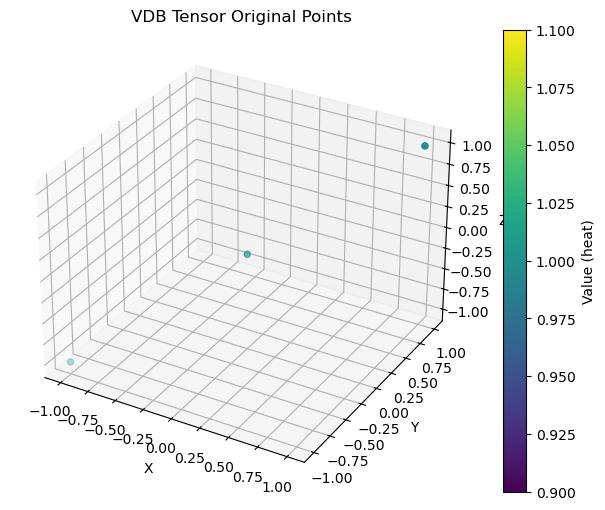

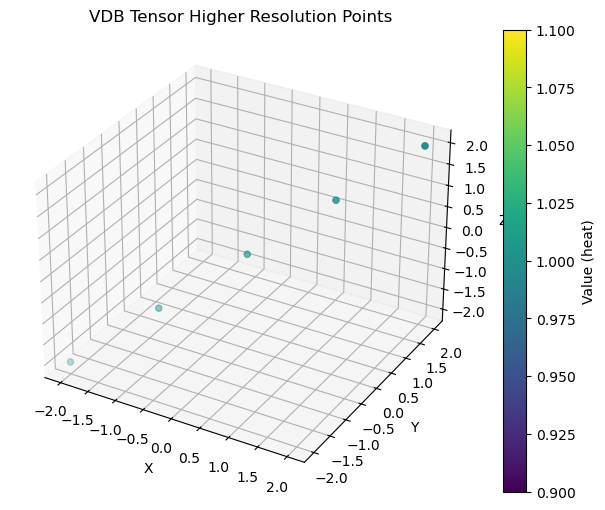

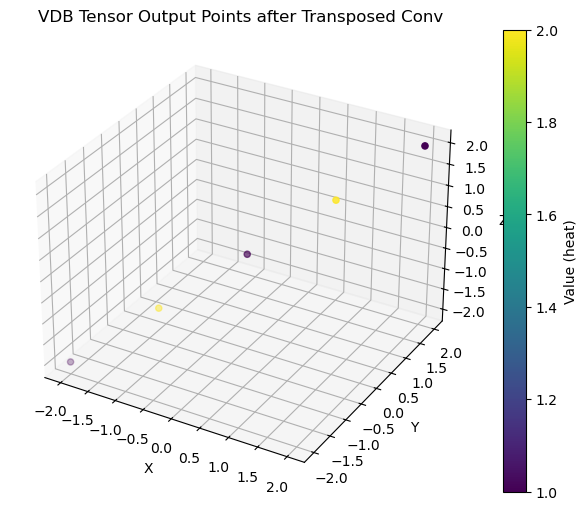

Output VDB Tensor:
Grid ijk: [[-2 -2 -2]
 [-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]
 [ 2  2  2]]
Data values: [[1.]
 [2.]
 [1.]
 [2.]
 [1.]]
shape of conv2 weight: torch.Size([1, 1, 3, 3, 3])
shape of t_conv2 weight: torch.Size([1, 1, 3, 3, 3])


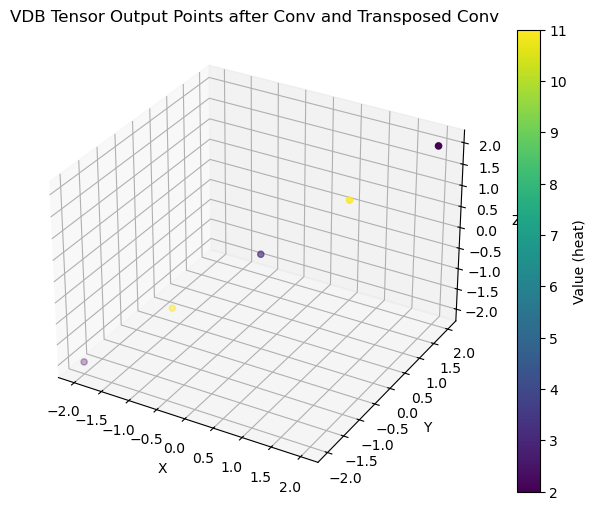

Output VDB Tensor after Conv:
Grid ijk: [[-1 -1 -1]
 [-1 -1  0]
 [-1  0 -1]
 [-1  0  0]
 [ 0 -1 -1]
 [ 0 -1  0]
 [ 0  0 -1]
 [ 0  0  0]
 [ 0  0  1]
 [ 0  1  0]
 [ 0  1  1]
 [ 1  0  0]
 [ 1  0  1]
 [ 1  1  0]
 [ 1  1  1]]
Data values: [[2.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [3.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [2.]]


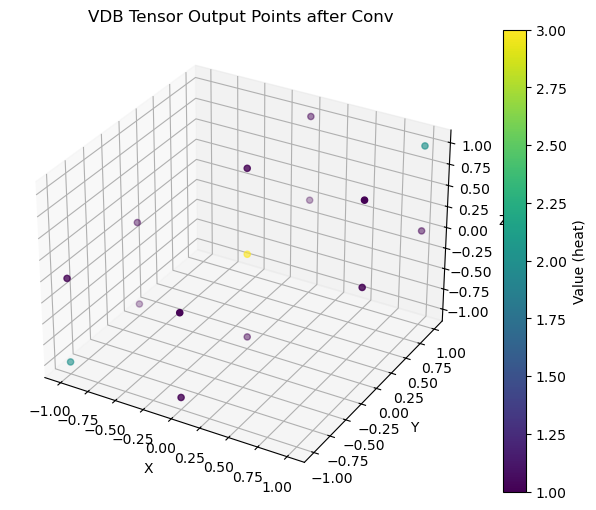

Output VDB Tensor after Transposed Conv:
Grid ijk: [[-2 -2 -2]
 [-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]
 [ 2  2  2]]
Data values: [[ 2.]
 [11.]
 [ 3.]
 [11.]
 [ 2.]]


In [5]:
##  when u define the output grid
def exp1():
    '''example of how to define the output grid'''
    # create a grid of the size with out nomalize actual shape
    lower_resolution_ijk = [[0,0,0], [1, 1, 1], [2,2,2]]
    # insert one point in between
    higher_resolution_ijk = [[0,0,0], [1, 1, 1], [2,2,2], [3,3,3], [4,4,4]]
    lower_resolution_ijk = torch.tensor(lower_resolution_ijk, dtype=torch.int, device=device)
    higher_resolution_ijk = torch.tensor(higher_resolution_ijk, dtype=torch.int, device=device)
    
    # normalize the ijk coordinates to be centered around (0, 0, 0)
    lower_resolution_ijk = lower_resolution_ijk - (len(lower_resolution_ijk)-1)//2
    higher_resolution_ijk = higher_resolution_ijk - (len(higher_resolution_ijk-1))//2

    # create a VDB tensor
    grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(lower_resolution_ijk), voxel_sizes=(1/3), origins=torch.tensor([0, 0, 0], device=device))
    values = torch.tensor(np.ones(3), dtype=torch.float32, device=device)

    # create a VDBTensor
    vdb_tensor = fvnn.VDBTensor(grid, grid.jagged_like(values[:, None]))

    # plot the grid
    points = vdb_tensor.grid.ijk.jdata.cpu().detach().numpy()
    values = vdb_tensor.data.jdata.cpu().detach().numpy()
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=values, cmap='viridis')
    # sc = ax.scatter(original_points[:, 0], original_points[:, 1], original_points[:, 2], c='red')
    plt.colorbar(sc, ax=ax, label='Value (heat)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('VDB Tensor Original Points')
    plt.show()

    # plot higher resolution
    big_grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(higher_resolution_ijk), voxel_sizes=(1/5), origins=torch.tensor([0, 0, 0], device=device))
    values = torch.tensor(np.ones(5), dtype=torch.float32, device=device)
    # create a new VDBTensor with the higher resolution grid
    big_vdb_tensor = fvnn.VDBTensor(big_grid, big_grid.jagged_like(values[:, None]))
    # plot the new grid
    big_points = big_vdb_tensor.grid.ijk.jdata.cpu().detach().numpy()
    big_values = big_vdb_tensor.data.jdata.cpu().detach().numpy()
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(big_points[:, 0], big_points[:, 1], big_points[:, 2], c=big_values, cmap='viridis')
    plt.colorbar(sc, ax=ax, label='Value (heat)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('VDB Tensor Higher Resolution Points')
    plt.show()

    # trannpose conv
    t_conv = fvnn.SparseConv3d(
        in_channels=1, 
        out_channels=1, 
        kernel_size=3, 
        stride=2, 
        transposed=True,
        bias=False).to(device)
    
    with torch.no_grad():
        t_conv.weight.fill_(1.0)  # fill the weights with 1.0 for simplicity

    
    # apply the transposed conv
    out_vdb_tensor = t_conv(vdb_tensor, out_grid=big_vdb_tensor.grid)
    
    # plot the output grid
    out_points = out_vdb_tensor.grid.ijk.jdata.cpu().detach().numpy()
    out_values = out_vdb_tensor.data.jdata.cpu().detach().numpy()
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(out_points[:, 0], out_points[:, 1], out_points[:, 2], c=out_values, cmap='viridis')
    plt.colorbar(sc, ax=ax, label='Value (heat)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('VDB Tensor Output Points after Transposed Conv')
    plt.show()
    # let also print the ouput of transposed conv
    print("Output VDB Tensor:")
    print("Grid ijk:", out_vdb_tensor.grid.ijk.jdata.cpu().detach().numpy())
    print("Data values:", out_vdb_tensor.data.jdata.cpu().detach().numpy())

    # conv then transpose conv
    conv2 = fvnn.SparseConv3d(
        in_channels=1, 
        out_channels=1, 
        kernel_size=3,
        stride=2,
        bias=False).to(device)
    with torch.no_grad():
        conv2.weight.fill_(1.0)
    t_conv2 = fvnn.SparseConv3d(
        in_channels=1, 
        out_channels=1, 
        kernel_size=3,
        stride=2,
        bias=False,
        transposed=True).to(device)
    
    with torch.no_grad():
        conv2.weight.fill_(1.0)
        print("shape of conv2 weight:", conv2.weight.shape)
    with torch.no_grad():
        t_conv2.weight.fill_(1.0)
        print("shape of t_conv2 weight:", t_conv2.weight.shape)

    # apply the conv
    out_vdb_tensor2_c = conv2(big_vdb_tensor)
    # apply the transposed conv
    out_vdb_tensor2 = t_conv2(out_vdb_tensor2_c, out_grid=big_vdb_tensor.grid)
    # plot the output grid
    out_points2 = out_vdb_tensor2.grid.ijk.jdata.cpu().detach().numpy()
    out_values2 = out_vdb_tensor2.data.jdata.cpu().detach().numpy()
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')  
    sc = ax.scatter(out_points2[:, 0], out_points2[:, 1], out_points2[:, 2], c=out_values2, cmap='viridis')
    plt.colorbar(sc, ax=ax, label='Value (heat)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('VDB Tensor Output Points after Conv and Transposed Conv')
    plt.show()
    # let also print the ouput of conv and transposed conv  
    print("Output VDB Tensor after Conv:")
    print("Grid ijk:", out_vdb_tensor2_c.grid.ijk.jdata.cpu().detach().numpy())
    print("Data values:", out_vdb_tensor2_c.data.jdata.cpu().detach().numpy())  
    # plot conv output
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(out_vdb_tensor2_c.grid.ijk.jdata.cpu().detach().numpy()[:, 0], 
                    out_vdb_tensor2_c.grid.ijk.jdata.cpu().detach().numpy()[:, 1], 
                    out_vdb_tensor2_c.grid.ijk.jdata.cpu().detach().numpy()[:, 2], 
                    c=out_vdb_tensor2_c.data.jdata.cpu().detach().numpy(), cmap='viridis')
    plt.colorbar(sc, ax=ax, label='Value (heat)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('VDB Tensor Output Points after Conv')
    plt.show() 
    print("Output VDB Tensor after Transposed Conv:")
    print("Grid ijk:", out_vdb_tensor2.grid.ijk.jdata.cpu().detach().numpy())
    print("Data values:", out_vdb_tensor2.data.jdata.cpu().detach().numpy())
exp1()

In [15]:
ijk = torch.randint(-20, 20, (20, 3), device='cuda')
print(ijk.shape, ijk.min(), ijk.max())
indices = torch.randperm(ijk.shape[0], device=ijk.device)[:10]
ijk_random_10 = ijk[indices]
print(ijk_random_10)
unique_rows = torch.unique(ijk_random_10, dim=0)
if unique_rows.shape[0] < ijk_random_10.shape[0]:
    print("There are repeated rows.")
else:
    print("All rows are unique.")
ijk_jagged = fvdb.JaggedTensor([ijk_random_10])

# Create Grid A with voxel size 1.0
voxel_sizes = [1.0, 1.0, 1.0]  # Single grid with uniform voxel size
voxel_sizes2 = [2.0, 2.0, 2.0]
origins = [0.0, 0.0, 0.0]      # Origin at (0, 0, 0)

# Create the GridBatch from the IJK coordinates
grid = fvdb.gridbatch_from_ijk(
    ijk=ijk_jagged,
    voxel_sizes=voxel_sizes,
    origins=origins
)
grid2 = fvdb.gridbatch_from_ijk(
    ijk=ijk_jagged,
    voxel_sizes=voxel_sizes2,
    origins=origins
)

# Define voxel values (e.g., all ones)
num_voxels = 10
values = torch.ones((num_voxels, 1), device='cuda')
data = grid.jagged_like(data=values)
data2 = grid2.jagged_like(data=values)

# Create the VDBTensor
vdb_tensor = fvnn.VDBTensor(grid=grid, data=data)
vdb_tensor2 = fvnn.VDBTensor(grid=grid2, data=data2)

torch.Size([20, 3]) tensor(-19, device='cuda:0') tensor(19, device='cuda:0')
tensor([[-19,  11,  -6],
        [  4, -19,  10],
        [ 19,  13,  -9],
        [-14,  -9, -14],
        [ 15,  14,   4],
        [  3,  -8,  10],
        [  7,   7, -13],
        [-16,   2,  10],
        [ 19,  17,   0],
        [-17,  19,  -1]], device='cuda:0')
All rows are unique.


In [16]:
# Define a simple convolution layer
conv = fvnn.SparseConv3d(
    in_channels=1,
    out_channels=1,
    kernel_size=1,
    stride=1,
    bias=False
).to(device)

# Apply convolution to both grids
out_a = conv(vdb_tensor)
out_b = conv(vdb_tensor2)

In [17]:
out_a.jdata.shape, out_a.jdata

(torch.Size([10, 1]),
 tensor([[0.3673],
         [0.3673],
         [0.3673],
         [0.3673],
         [0.3673],
         [0.3673],
         [0.3673],
         [0.3673],
         [0.3673],
         [0.3673]], device='cuda:0', grad_fn=<MmBackward0>))

Text(0.5, 0, 'Z')

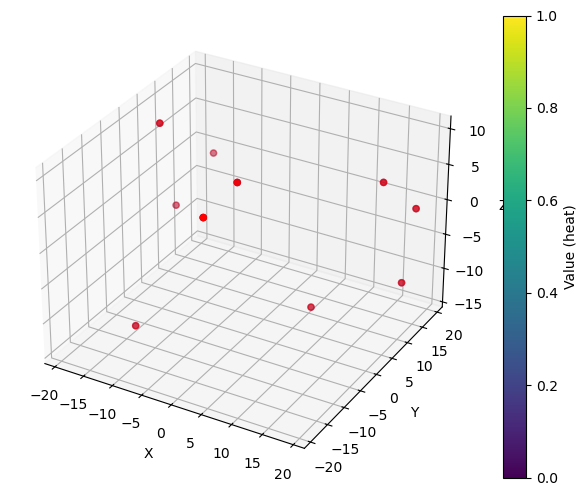

In [18]:
# plot the results
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Suppose points is (N, 3) and values is (N,)
original_points = vdb_tensor.grid.ijk.jdata.cpu().numpy()  # shape (N, 3)
points = out_a.ijk.jdata.cpu().numpy()      # shape (N, 3)
values = out_a.jdata.detach().cpu().numpy()  # shape (N,)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=values, cmap='viridis')
sc = ax.scatter(original_points[:, 0], original_points[:, 1], original_points[:, 2], c='red')
plt.colorbar(sc, ax=ax, label='Value (heat)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

In [19]:
(out_a.jdata == out_b.jdata)

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

In [20]:
new_ijk = []
for _, _ijk in enumerate(ijk_random_10):
    # choose random int from 0 to 2
    idx = random.randint(0, 2)
    new_ijk.append(_ijk + torch.tensor([0, 0, 2], device='cuda') if idx == 0 else _ijk + torch.tensor([0, 2, 0], device='cuda') if idx == 1 else _ijk + torch.tensor([2, 0, 0], device='cuda'))
new_ijk = torch.stack(new_ijk, dim=0)
# append new_ijk to ijk_random_10
new_ijk = torch.cat([ijk_random_10, new_ijk], dim=0)
new_ijk


tensor([[-19,  11,  -6],
        [  4, -19,  10],
        [ 19,  13,  -9],
        [-14,  -9, -14],
        [ 15,  14,   4],
        [  3,  -8,  10],
        [  7,   7, -13],
        [-16,   2,  10],
        [ 19,  17,   0],
        [-17,  19,  -1],
        [-19,  13,  -6],
        [  4, -17,  10],
        [ 19,  13,  -7],
        [-12,  -9, -14],
        [ 17,  14,   4],
        [  3,  -8,  12],
        [  7,   9, -13],
        [-16,   2,  12],
        [ 19,  19,   0],
        [-15,  19,  -1]], device='cuda:0')

In [21]:
# create upsampled grid

ijk_jagged_upsampled = fvdb.JaggedTensor([2*ijk])
grid_upsampled = fvdb.gridbatch_from_ijk(
    ijk=ijk_jagged_upsampled,
    voxel_sizes=[1, 1, 1],  # Half the voxel size
    origins=origins
)
grid_upsampled2 = fvdb.gridbatch_from_ijk(
    ijk=ijk_jagged_upsampled,
    voxel_sizes=[2.0, 2.0, 2.0],  # Half the voxel size
    origins=origins
)
values = torch.ones((20, 1), device='cuda')
data_upsampled = grid_upsampled.jagged_like(data=values)
data_upsampled2 = grid_upsampled2.jagged_like(data=values)

# Create the upsampled VDBTensor
vdb_tensor_upsampled = fvnn.VDBTensor(grid=grid_upsampled, data=data_upsampled)
vdb_tensor_upsampled2 = fvnn.VDBTensor(grid=grid_upsampled2, data=data_upsampled2)

In [22]:
conv_t = fvnn.SparseConv3d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=2,
    transposed=True,
    bias=False
).to(device)

with torch.no_grad():
    # conv_t.weight[:] = 2.0
    print(conv_t.weight)

out_a = conv_t(vdb_tensor, out_grid=grid_upsampled)
out_b = conv_t(vdb_tensor, out_grid=grid_upsampled2)
(out_a.jdata == out_b.jdata).all()

Parameter containing:
tensor([[[[[-0.0212, -0.1445, -0.0850],
           [ 0.1432, -0.0139, -0.1886],
           [-0.1152, -0.0588,  0.0232]],

          [[-0.0296,  0.0781, -0.1123],
           [ 0.0010, -0.1189,  0.0475],
           [-0.0736, -0.0147, -0.1883]],

          [[-0.1477,  0.0716,  0.1726],
           [ 0.0284, -0.0713, -0.1350],
           [-0.0332, -0.0802, -0.0520]]]]], device='cuda:0',
       requires_grad=True)


tensor(True, device='cuda:0')

In [23]:
# grid_upsampled.ijk.jdata

In [24]:
vdb_tensor.bbox, vdb_tensor_upsampled.bbox, vdb_tensor_upsampled2.bbox

(tensor([[[-19, -19, -14],
          [ 19,  19,  10]]], device='cuda:0', dtype=torch.int32),
 tensor([[[-38, -38, -28],
          [ 38,  38,  36]]], device='cuda:0', dtype=torch.int32),
 tensor([[[-38, -38, -28],
          [ 38,  38,  36]]], device='cuda:0', dtype=torch.int32))

In [25]:
def plot_(out_a, vdb_tensor):
    original_points = vdb_tensor.grid.ijk.jdata.cpu().numpy()
    points = out_a.ijk.jdata.cpu().numpy()      # shape (N, 3)
    values = out_a.jdata.detach().cpu().numpy()  # shape (N,)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=values, cmap='viridis')
    sc = ax.scatter(original_points[:, 0], original_points[:, 1], original_points[:, 2], c='red')
    plt.colorbar(sc, ax=ax, label='Value (heat)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

In [26]:
# dowsample then aplsample can also work neaerby points

torch.Size([147, 1])
torch.Size([540, 1])


(torch.Size([20, 1]),
 tensor([[-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0010],
         [-0.0070],
         [-0.0070],
         [-0.0070],
         [-0.0070],
         [-0.0070],
         [-0.0070],
         [-0.0070],
         [-0.0070],
         [-0.0070],
         [-0.0070]], device='cuda:0', grad_fn=<SparseConvolutionImplicitGEMM>>),
 tensor([[ 0.0000],
         [-0.1189],
         [ 0.0000],
         [ 0.0000],
         [-0.1189],
         [-0.1189],
         [ 0.0000],
         [ 0.0000],
         [-0.1189],
         [ 0.0000],
         [ 0.0000],
         [-0.1189],
         [-0.1189],
         [-0.1189],
         [ 0.0000],
         [-0.1189],
         [ 0.0000],
         [-0.1189],
         [ 0.0000],
         [-0.1189]], device='cuda:0', grad_fn=<SparseConvolutionImplicitGEMM>>),
 None)

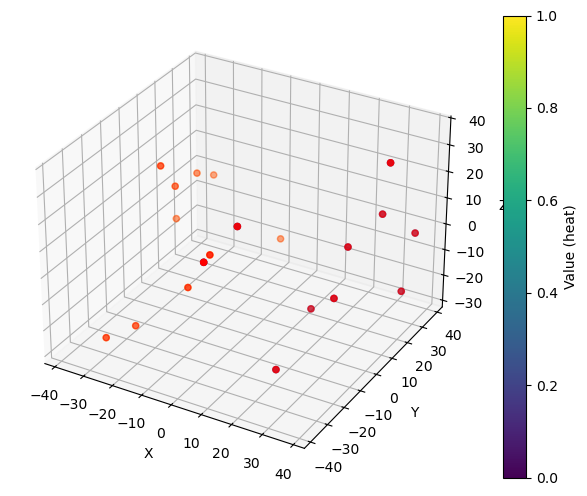

In [27]:
conv2 = fvnn.SparseConv3d(
    in_channels=1,
    out_channels=1,
    kernel_size=5,
    stride=2,
    # transposed=True,
    # bias=False
).to(device)
out_c_b = conv2(vdb_tensor)
print(out_c_b.jdata.shape)
values2 = torch.cat([
    torch.ones((10, 1), device='cuda'),
    torch.zeros((10, 1), device='cuda')
], dim=0)
vdb_tensor_exp = fvnn.VDBTensor(grid=grid_upsampled, data=grid_upsampled.jagged_like(values2))
out_c_3 = conv2(vdb_tensor_exp)
print(out_c_3.jdata.shape)
out_c_3 = conv_t(out_c_3, out_grid=vdb_tensor_exp.grid)
out_c_1 = conv_t(vdb_tensor, out_grid=grid_upsampled2)
out_c_2 = conv_t(out_c_b, out_grid=grid_upsampled2)
# (out_c_1.jdata==out_c_2.jdata).all(), 
out_c_1.jdata.shape, out_c_3.jdata, out_c_1.jdata, plot_(out_c_3, vdb_tensor_exp)

In [181]:
# ijk
# m3g = torch.tensor(mt.mesh_grid(3),device=device)-1
# (2*ijk[:, None, :]+ m3g[None, :, :]).view(-1, 3).shape

In [91]:
out_b.jdata.shape, out_a.jdata, out_b.jdata

(torch.Size([20, 1]),
 tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.]], device='cuda:0', grad_fn=<SparseConvolutionImplicitGEMM>>),
 tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.]], device='cuda:0', grad_fn=<SparseConvolutionImplicitGEMM>>))